# Lending Risk & Borrower Behavior Analysis using Association Rules (Apriori)

Fase 3: Association Rule Mining

Pada fase ini saya menerapkan algoritma Apriori untuk menggali pola co-occurrence
(kemunculan bersama) antar atribut pinjaman yang tidak terlihat dari tabulasi biasa.
Saya menjalankan pipeline penuh: membaca data hasil diskretisasi dari Fase 1,
menentukan threshold secara data-driven, menambang frequent itemset, membentuk
association rules, membersihkan rule yang trivial dan redundan, lalu menerjemahkan
temuan ke dalam bahasa bisnis.

Saya menambang dua dataset agar bisa melakukan perbandingan lintas domain:
- Accepted loans: fokus utama, memuat outcome pinjaman (loan_status).
- Rejected loans: dataset komparatif untuk memahami karakter pengajuan yang ditolak.


# 1. Data Ingestion & Initial Observation

Saya memuat dataset accepted yang sudah dibersihkan dan didiskretisasi pada Fase 1.
Semua kolom sudah berbentuk biner 0/1 (hasil binning domain-based + One-Hot Encoding),
sehingga siap langsung saya masukkan ke Apriori tanpa transformasi tambahan.

In [1]:
# %pip install mlxtend --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Memuat dataset accepted (hasil diskretisasi Fase 1)...")
df = pd.read_csv('../Datasets/Cleaning/Phase 3/clean_for_apriori_accepted.csv')
print(f"Dimensi dataset: {df.shape[0]:,} transaksi x {df.shape[1]} item biner")

Memuat dataset accepted (hasil diskretisasi Fase 1)...
Dimensi dataset: 1,348,099 transaksi x 74 item biner


In [3]:
df.head()

,home_ownership_MORTGAGE,home_ownership_RENT,home_ownership_NONE,home_ownership_OTHER,home_ownership_OWN,int_rate_bin_Very Low (<8%),int_rate_bin_Low (8-12%),int_rate_bin_Medium (12-16%),int_rate_bin_High (16-20%),int_rate_bin_Very High (>20%),dti_bin_Very Low (<10),dti_bin_Low (10-20),dti_bin_Medium (20-30),dti_bin_High (30-40),dti_bin_Very High (>40),income_bin_Low (<30K),income_bin_Lower-Mid (30-60K),income_bin_Mid (60-100K),income_bin_High (100-200K),income_bin_Very High (>200K),loan_amnt_bin_Micro (<5K),loan_amnt_bin_Small (5-10K),loan_amnt_bin_Medium (10-20K),loan_amnt_bin_Large (20-35K),loan_amnt_bin_Very Large (>35K),loan_status_Charged Off,loan_status_Default,loan_status_Does not meet the credit policy. Status:Charged Off,loan_status_Does not meet the credit policy. Status:Fully Paid,loan_status_Fully Paid,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,sub_grade_A1,sub_grade_A2,sub_grade_A3,sub_grade_A4,sub_grade_A5,sub_grade_B1,sub_grade_B2,sub_grade_B3,sub_grade_B4,sub_grade_B5,sub_grade_C1,sub_grade_C2,sub_grade_C3,sub_grade_C4,sub_grade_C5,sub_grade_D1,sub_grade_D2,sub_grade_D3,sub_grade_D4,sub_grade_D5,sub_grade_E1,sub_grade_E2,sub_grade_E3,sub_grade_E4,sub_grade_E5,sub_grade_F1,sub_grade_F2,sub_grade_F3,sub_grade_F4,sub_grade_F5,sub_grade_G1,sub_grade_G2,sub_grade_G3,sub_grade_G4,sub_grade_G5,term_36,term_60
0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1
4,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [4]:
# Saya memastikan seluruh kolom benar-benar biner (0/1) sebelum menambang.
# Apriori pada mlxtend mengasumsikan matriks transaksi biner; nilai selain 0/1
# akan menghasilkan support yang salah.
is_binary = df.isin([0, 1]).all().all()
print(f"Semua kolom bernilai biner (0/1): {is_binary}")
print(f"Jumlah item unik (kolom): {df.shape[1]}")
print(f"\nDaftar item:")
for c in df.columns:
    print(f"  - {c}")

Semua kolom bernilai biner (0/1): True
Jumlah item unik (kolom): 74

Daftar item:
  - home_ownership_MORTGAGE
  - home_ownership_RENT
  - home_ownership_NONE
  - home_ownership_OTHER
  - home_ownership_OWN
  - int_rate_bin_Very Low (<8%)
  - int_rate_bin_Low (8-12%)
  - int_rate_bin_Medium (12-16%)
  - int_rate_bin_High (16-20%)
  - int_rate_bin_Very High (>20%)
  - dti_bin_Very Low (<10)
  - dti_bin_Low (10-20)
  - dti_bin_Medium (20-30)
  - dti_bin_High (30-40)
  - dti_bin_Very High (>40)
  - income_bin_Low (<30K)
  - income_bin_Lower-Mid (30-60K)
  - income_bin_Mid (60-100K)
  - income_bin_High (100-200K)
  - income_bin_Very High (>200K)
  - loan_amnt_bin_Micro (<5K)
  - loan_amnt_bin_Small (5-10K)
  - loan_amnt_bin_Medium (10-20K)
  - loan_amnt_bin_Large (20-35K)
  - loan_amnt_bin_Very Large (>35K)
  - loan_status_Charged Off
  - loan_status_Default
  - loan_status_Does not meet the credit policy. Status:Charged Off
  - loan_status_Does not meet the credit policy. Status:Fully Paid

Setiap kolom saya perlakukan sebagai satu item dalam keranjang transaksi.
Satu baris merepresentasikan satu pinjaman, dan nilai 1 berarti item tersebut
melekat pada pinjaman itu (misalnya grade_A = 1 berarti pinjaman ini ber-grade A).
Karena kolom berasal dari binning domain (misalnya int_rate_bin dan dti_bin) serta
One-Hot Encoding kategori, setiap item sudah bermakna secara bisnis dan siap saya
ceritakan ketika muncul di dalam rule.

# 2. Eksplorasi Frekuensi Item (Support Individual)

Sebelum menambang kombinasi, saya memeriksa dulu support masing-masing item.
Langkah ini membantu saya memahami item mana yang dominan dan item mana yang langka,
sekaligus menjadi dasar untuk memilih min_support yang masuk akal pada langkah berikutnya.

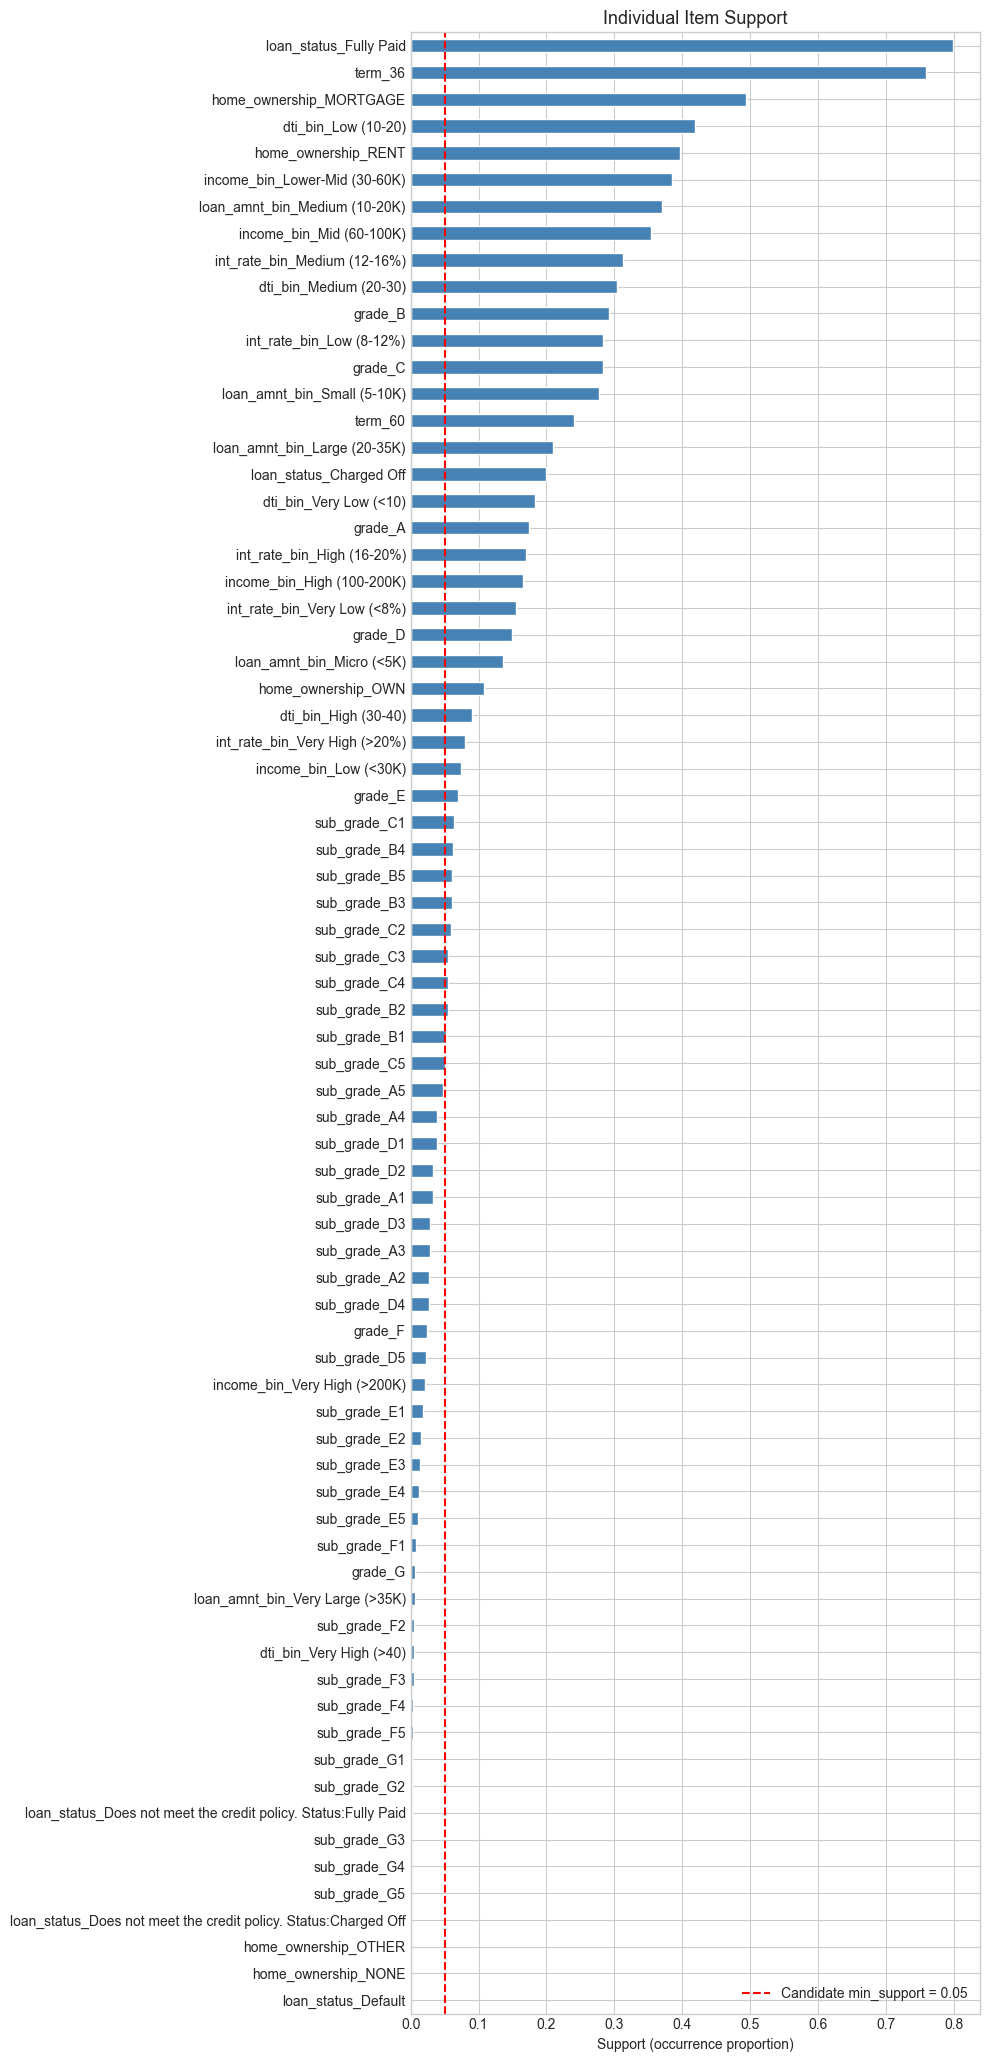

Most frequent items:
loan_status_Fully Paid           0.799
term_36                          0.759
home_ownership_MORTGAGE          0.495
dti_bin_Low (10-20)              0.418
home_ownership_RENT              0.397
income_bin_Lower-Mid (30-60K)    0.385
loan_amnt_bin_Medium (10-20K)    0.370
income_bin_Mid (60-100K)         0.355

Least frequent items:
loan_status_Does not meet the credit policy. Status:Fully Paid     0.001
sub_grade_G3                                                       0.001
sub_grade_G4                                                       0.001
sub_grade_G5                                                       0.001
loan_status_Does not meet the credit policy. Status:Charged Off    0.001
home_ownership_OTHER                                               0.000
home_ownership_NONE                                                0.000
loan_status_Default                                                0.000


In [5]:
# Support tiap item = rata-rata kolom (karena biner, mean = proporsi kemunculan)
item_support = df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, max(6, len(item_support) * 0.28)))
item_support.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Support (occurrence proportion)')
ax.set_title('Individual Item Support', fontsize=13)
ax.axvline(x=0.05, color='red', linestyle='--', label='Candidate min_support = 0.05')
ax.legend()
plt.tight_layout()
plt.savefig('Results/results_item_support.png', dpi=120, bbox_inches='tight')
plt.show()

print("Most frequent items:")
print(item_support.head(8).round(3).to_string())
print("\nLeast frequent items:")
print(item_support.tail(8).round(3).to_string())

Dari grafik ini saya melihat bahwa sebagian item sangat dominan (misalnya term dan
grade yang populer), sementara sebagian lagi jarang muncul. Item yang support-nya jauh
di bawah 5% tidak akan mampu membentuk itemset yang lolos threshold, jadi saya sudah
bisa memperkirakan bahwa rule akan berpusat pada item-item yang cukup umum. Ini penting
supaya insight yang dihasilkan mewakili kelompok nasabah yang bervolume besar,
bukan kasus langka yang tidak bisa dijadikan dasar kebijakan.

# 3. Penentuan Threshold secara Data-Driven

Alih-alih menebak nilai min_support, saya menjalankan sensitivity sweep: saya coba
beberapa nilai min_support lalu mengamati berapa banyak frequent itemset dan rule yang
dihasilkan. Tujuan saya adalah memilih titik yang menyeimbangkan dua hal: cukup banyak
rule untuk digali (minimal 10 sesuai rubrik) tetapi tidak meledak menjadi ribuan rule
langka yang tidak actionable.

In [6]:
# Sweep min_support untuk melihat sensitivitas jumlah itemset dan rule.
support_grid = [0.02, 0.03, 0.05, 0.08, 0.10, 0.15, 0.2]
sweep_rows = []

for s in support_grid:
    fi = apriori(df, min_support=s, use_colnames=True, low_memory=True)
    n_itemsets = len(fi)
    # Hitung rule dengan lift >= 2 pada tiap level support
    if n_itemsets > 0:
        try:
            r = association_rules(fi, metric="lift", min_threshold=2)
            n_rules = len(r)
        except Exception:
            n_rules = 0
    else:
        n_rules = 0
    sweep_rows.append({'min_support': s, 'n_itemsets': n_itemsets, 'n_rules_lift>=2': n_rules})
    print(f"min_support={s:<5} -> {n_itemsets:>5} itemsets | {n_rules:>5} rules (lift>=2)")

sweep_df = pd.DataFrame(sweep_rows)

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.02  ->  3040 itemsets | 10018 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.03  ->  1670 itemsets |  4102 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


...

min_support=0.1   ->   215 itemsets |    96 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.15  ->    90 itemsets |    34 rules (lift>=2)


c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


min_support=0.2   ->    56 itemsets |    12 rules (lift>=2)


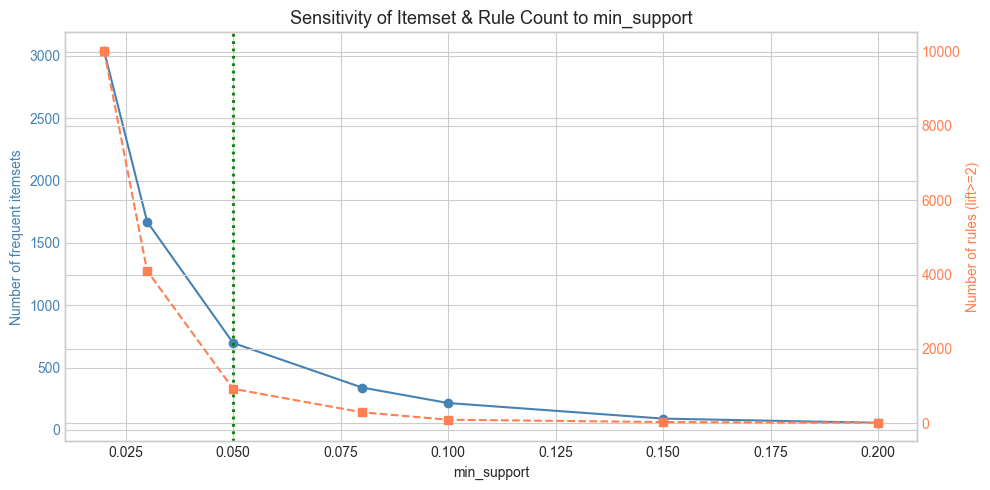

In [7]:
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(sweep_df['min_support'], sweep_df['n_itemsets'], 'o-', color='steelblue', label='Frequent itemsets')
ax1.set_xlabel('min_support')
ax1.set_ylabel('Number of frequent itemsets', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(sweep_df['min_support'], sweep_df['n_rules_lift>=2'], 's--', color='coral', label='Rules (lift>=2)')
ax2.set_ylabel('Number of rules (lift>=2)', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

ax1.axvline(x=0.05, color='green', linestyle=':', linewidth=2, label='Chosen: 0.05')
ax1.set_title('Sensitivity of Itemset & Rule Count to min_support', fontsize=13)
fig.tight_layout()

plt.savefig('Results/results_support_sweep.png', dpi=120, bbox_inches='tight')
plt.show()


Justifikasi pemilihan threshold:

min_support = 0.05
Saya memilih 5% karena dari sweep terlihat inilah titik keseimbangan yang baik. Di bawah
titik ini jumlah itemset naik tajam dan mulai memunculkan kombinasi yang hanya terjadi
pada segelintir nasabah, sehingga tidak cukup kuat untuk dijadikan dasar kebijakan bank.
Nilai 5% memastikan setiap pola yang saya ambil mewakili minimal 5% dari seluruh transaksi
pinjaman, sehingga aksi bisnis yang saya rekomendasikan berdampak pada volume yang berarti.

metric = "lift" dengan min_threshold = 2.
Saya menyaring rule menggunakan lift, bukan sekadar confidence. Confidence bisa menyesatkan
ketika consequent-nya memang sudah populer, sedangkan lift mengukur seberapa jauh kemunculan
bersama antecedent dan consequent melampaui ekspektasi jika keduanya independen. Saya memakai
ambang lift >= 2 agar hanya menyimpan rule yang kemunculannya minimal dua kali lebih sering
dibanding kebetulan statistik. Ini menyaring korelasi yang benar-benar berarti dan membuang
asosiasi yang lemah.

# 4. Frequent Itemset Mining (Apriori)

Dengan threshold yang sudah saya justifikasi, saya menjalankan Apriori untuk menemukan
seluruh frequent itemset, lalu memeriksa komposisinya berdasarkan panjang itemset.

In [8]:
frequent_itemsets = apriori(df, min_support=0.05, use_colnames=True, low_memory=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print("\nDistribution by itemset length:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

c:\Users\stiev\anaconda3\envs\Machine_Learning\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Total frequent itemsets found: 697

Distribution by itemset length:
length
1     39
2    204
3    291
4    143
5     20


In [9]:
# Saya menampilkan itemset dengan support tertinggi di tiap panjang untuk memahami
# pola dominan sebelum membentuk rule.
for L in sorted(frequent_itemsets['length'].unique()):
    subset = frequent_itemsets[frequent_itemsets['length'] == L].nlargest(5, 'support').copy()
    subset['itemsets'] = subset['itemsets'].apply(lambda x: ', '.join(list(x)))
    print(f"=== Top itemsets of length {L} ===")
    print(subset[['itemsets', 'support']].round(3).to_string(index=False))
    print()

=== Top itemsets of length 1 ===
               itemsets  support
 loan_status_Fully Paid    0.799
                term_36    0.759
home_ownership_MORTGAGE    0.495
    dti_bin_Low (10-20)    0.418
    home_ownership_RENT    0.397

=== Top itemsets of length 2 ===
                                       itemsets  support
                term_36, loan_status_Fully Paid    0.636
loan_status_Fully Paid, home_ownership_MORTGAGE    0.409
               term_36, home_ownership_MORTGAGE    0.354
    dti_bin_Low (10-20), loan_status_Fully Paid    0.343
                   term_36, home_ownership_RENT    0.320

=== Top itemsets of length 3 ===
                                                      itemsets  support
      term_36, loan_status_Fully Paid, home_ownership_MORTGAGE    0.307
          dti_bin_Low (10-20), term_36, loan_status_Fully Paid    0.273
          term_36, loan_status_Fully Paid, home_ownership_RENT    0.259
term_36, loan_status_Fully Paid, income_bin_Lower-Mid (30-60K)    0.249

Distribusi panjang itemset menunjukkan bahwa Apriori berhasil menemukan tidak hanya
item tunggal, tetapi juga kombinasi dua item atau lebih yang sering muncul bersama.
Kombinasi berukuran dua atau lebih inilah yang nantinya menjadi bahan baku rule yang menarik,
karena mereka mengungkap keterkaitan antar atribut yang tidak terlihat dari frekuensi
item tunggal.

# 5. Association Rule Generation

Saya membentuk association rules dari frequent itemset, lalu menghitung Support,
Confidence, dan Lift untuk setiap rule. Ketiga metrik ini saya gunakan bersama-sama
untuk menilai kualitas rule, bukan hanya salah satunya.

In [10]:
rules = association_rules(frequent_itemsets.drop(columns='length'),
                         metric="lift", min_threshold=2)
rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)

print(f"Total initial rules (lift >= 2): {len(rules)}")
print("\nMetric summary statistics:")
print(rules[['support', 'confidence', 'lift']].describe().round(3).to_string())

Total initial rules (lift >= 2): 928

Metric summary statistics:
       support  confidence     lift
count  928.000     928.000  928.000
mean     0.076       0.572    3.560
std      0.031       0.277    1.084
min      0.050       0.160    2.012
25%      0.056       0.309    2.880
50%      0.068       0.563    3.063
75%      0.083       0.853    3.526
max      0.254       1.000    5.846


In [11]:
# Fungsi bantu untuk menampilkan rule secara rapi (frozenset -> string).
def pretty_rules(df_input):
    d = df_input.copy()
    d['antecedents'] = d['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['consequents'] = d['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
    d['support'] = d['support'].round(3)
    d['confidence'] = d['confidence'].round(3)
    d['lift'] = d['lift'].round(3)
    return d[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

pd.set_option('display.max_rows', 30)
pretty_rules(rules).head(15)

,antecedents,consequents,support,confidence,lift
0,sub_grade_B4,grade_B,0.062,1.0,3.429
1,sub_grade_B3,grade_B,0.061,1.0,3.429
2,sub_grade_B2,grade_B,0.055,1.0,3.429
3,sub_grade_B1,grade_B,0.053,1.0,3.429
4,sub_grade_C3,grade_C,0.056,1.0,3.526
5,sub_grade_C2,grade_C,0.059,1.0,3.526
6,sub_grade_B5,grade_B,0.061,1.0,3.429
7,sub_grade_C1,grade_C,0.064,1.0,3.526
8,sub_grade_C5,grade_C,0.050,1.0,3.526
9,sub_grade_C4,grade_C,0.055,1.0,3.526


# 6. Rule Post-Processing & Optimization

Rule mentah masih mengandung dua jenis "kebisingan" yang harus saya buang agar hanya
menyisakan temuan non-trivial: rule yang secara logika pasti benar (trivial) dan rule
yang terlalu spesifik tanpa menambah informasi (redundan).

## 6.1 Trivial Knowledge Filtering (Redundansi Logis)

Saya membuang rule yang secara definisi pasti benar. Contohnya sub_grade_B2 -> grade_B:
karena B2 memang bagian dari Grade B, rule ini tidak memberi insight apa pun. Rule seperti
ini punya lift tinggi hanya karena hubungan definisi, bukan karena pola perilaku nyata.

In [12]:
def filter_trivial_rules(rules_df):
    def is_trivial(row):
        items = list(row['antecedents']) + list(row['consequents'])
        ant, cons = row['antecedents'], row['consequents']
        # (a) sub_grade dan grade dengan huruf sama muncul di satu rule
        #     contoh: sub_grade_B2 -> grade_B, atau grade_B -> sub_grade_B2.
        #     Ini hubungan definisi (B2 bagian dari Grade B), bukan temuan.
        sub_letters = {it.split('_')[-1][0] for it in items if it.startswith('sub_grade_')}
        grade_letters = {it.replace('grade_', '') for it in items
                         if it.startswith('grade_') and not it.startswith('sub_grade_')}
        if sub_letters & grade_letters:
            return True
        # (b) sub_grade dari huruf yang sama di kedua sisi (mis. sub_grade_B1 -> sub_grade_B2)
        ant_sub = {it.split('_')[-1][0] for it in ant if it.startswith('sub_grade_')}
        cons_sub = {it.split('_')[-1][0] for it in cons if it.startswith('sub_grade_')}
        if ant_sub & cons_sub:
            return True
        return False
    return rules_df[~rules_df.apply(is_trivial, axis=1)].copy()

rules_filtered = filter_trivial_rules(rules)
print(f"Rules before trivial filter : {len(rules)}")
print(f"Rules after trivial filter  : {len(rules_filtered)}")
print(f"Trivial rules removed       : {len(rules) - len(rules_filtered)}")

Rules before trivial filter : 928
Rules after trivial filter  : 840
Trivial rules removed       : 88


## 6.2 Superset Pruning Dua Sisi (Redundansi Struktural)

Saya menghapus rule yang terlalu spesifik tanpa memberi peningkatan confidence, pada
kedua sisi rule:

- Sisi antecedent: jika fico_High -> bunga_rendah sudah punya confidence 80%, maka
  fico_High, punya_mobil -> bunga_rendah yang confidence-nya juga 80% saya buang, karena
  menambahkan "punya mobil" tidak mengubah hasil dan hanya membuat rule lebih rumit.
- Sisi consequent: jika DTI_Tinggi -> Pinjaman_Besar punya confidence 37%, maka
  DTI_Tinggi -> Pinjaman_Besar, Kerja_Junior yang confidence-nya lebih rendah (34%) saya
  buang, karena menambahkan item di sisi akibat justru melemahkan rule.

Saya menyimpan versi paling ringkas dan paling percaya diri dari tiap pola. Fungsi yang sama
(remove_redundant_rules) dipakai identik untuk dataset accepted maupun rejected, sehingga
metode pembersihan kedua domain benar-benar konsisten.

In [13]:
def remove_redundant_rules(rules_df):
    """Superset pruning DUA SISI (dipakai identik untuk accepted & rejected).
    Buang rule yang lebih spesifik bila TIDAK menambah confidence dibanding rule
    yang lebih umum, pada kedua sisi:
      (a) consequent sama, antecedent superset -> buang yang antecedent-nya lebih besar
      (b) antecedent sama, consequent superset  -> buang yang consequent-nya lebih besar
    Rule yang lebih ringkas dengan confidence >= selalu diprioritaskan tetap tinggal.
    Sisi (b) penting: menutup kasus seperti {DTI Very High} -> {Amount Large, Junior}
    (conf 0,341) yang redundan terhadap {DTI Very High} -> {Amount Large} (conf 0,370)."""
    rules_df = rules_df.copy()
    rules_df["total_len"] = (rules_df["antecedents"].apply(len)
                             + rules_df["consequents"].apply(len))
    # Rule paling ringkas dan paling percaya diri diprioritaskan tetap tinggal
    rules_df = rules_df.sort_values(by=["total_len", "confidence"], ascending=[True, False])

    indices_to_drop = set()
    records = list(rules_df.iterrows())
    for i, row_a in records:
        if i in indices_to_drop:
            continue
        for j, row_b in records:
            if i == j or j in indices_to_drop:
                continue
            # (a) consequent identik, antecedent row_a superset dari row_b
            case_ante = (row_a['consequents'] == row_b['consequents']
                         and row_b['antecedents'].issubset(row_a['antecedents'])
                         and row_a['antecedents'] != row_b['antecedents'])
            # (b) antecedent identik, consequent row_a superset dari row_b
            case_cons = (row_a['antecedents'] == row_b['antecedents']
                         and row_b['consequents'].issubset(row_a['consequents'])
                         and row_a['consequents'] != row_b['consequents'])
            if (case_ante or case_cons) and row_a['confidence'] <= row_b['confidence'] + 1e-9:
                indices_to_drop.add(i)
                break
    return rules_df.drop(index=list(indices_to_drop)).drop(columns=["total_len"])

rules_final = remove_redundant_rules(rules_filtered)

# Redundansi simetris: buang X -> Y bila Y -> X dari itemset gabungan yang sama sudah ada;
# simpan hanya arah dengan confidence tertinggi. DITAMBAHKAN agar pipeline accepted IDENTIK
# dengan rejected (Bagian 9). Pada accepted, consequent hampir selalu grade/status yang tak
# muncul sebagai antecedent, sehingga umumnya tak ada pasangan simetris; jumlah dilaporkan.
n_before_sym = len(rules_final)
rules_final = rules_final.copy()
rules_final['sig'] = rules_final.apply(
    lambda r: frozenset(r['antecedents']) | frozenset(r['consequents']), axis=1)
rules_final = (rules_final.sort_values('confidence', ascending=False)
                          .drop_duplicates('sig', keep='first')
                          .drop(columns='sig')
                          .reset_index(drop=True))

print(f"Rules after trivial filter    : {len(rules_filtered)}")
print(f"Rules after superset prune    : {n_before_sym}")
print(f"Rules after symmetric dedup   : {len(rules_final)} "
      f"({n_before_sym - len(rules_final)} pasangan simetris dibuang)")

Rules after trivial filter    : 840
Rules after superset prune    : 246
Rules after symmetric dedup   : 106 (140 pasangan simetris dibuang)


# 7. Final Optimized Knowledge Base

Setelah dua tahap pembersihan, saya mengurutkan rule final berdasarkan lift tertinggi
(rule paling "mengejutkan" secara statistik ada di atas) dan menyimpannya ke CSV.
Saya juga menandai top rule agar mudah dirujuk pada bagian interpretasi.

In [14]:
final_rules_clean = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
final_rules_clean.to_csv("Results/results_apriori_cleaned.csv", index=False)

print(f"Total final non-trivial rules: {len(final_rules_clean)}")
print("File 'results_apriori_cleaned.csv' created successfully.")
print("\n=== Top 15 Rules by Lift ===")
final_rules_clean.head(15)

Total final non-trivial rules: 106
File 'results_apriori_cleaned.csv' created successfully.

=== Top 15 Rules by Lift ===


,antecedents,consequents,support,confidence,lift
0,"grade_A, loan_status_Fully Paid, term_36",int_rate_bin_Very Low (<8%),0.142,0.891,5.761
1,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%)","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
2,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K)","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
3,"grade_A, income_bin_Mid (60-100K)",int_rate_bin_Very Low (<8%),0.060,0.888,5.740
4,"dti_bin_Low (10-20), grade_A, loan_status_Fully Paid","int_rate_bin_Very Low (<8%), term_36",0.067,0.866,5.730
5,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), term_36",grade_A,0.087,0.999,5.728
6,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), loan_status_Fully Paid, term_36",grade_A,0.082,0.999,5.728
7,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%), loan_status_Fully Paid, term_36",grade_A,0.055,0.999,5.726
8,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%), term_36",grade_A,0.059,0.999,5.726
9,"dti_bin_Low (10-20), int_rate_bin_Very Low (<8%), term_36",grade_A,0.071,0.999,5.726


## 7.1 Visualisasi Rule (Support vs Confidence vs Lift)

Saya memvisualisasikan seluruh rule final dalam satu scatter plot: sumbu x adalah support,
sumbu y adalah confidence, dan warna serta ukuran titik merepresentasikan lift. Grafik ini
membantu saya (dan pembaca non-teknis di Fase 5) melihat sekaligus rule mana yang kuat,
sering, dan meyakinkan. Rule ideal berada di kanan atas dengan warna paling terang.

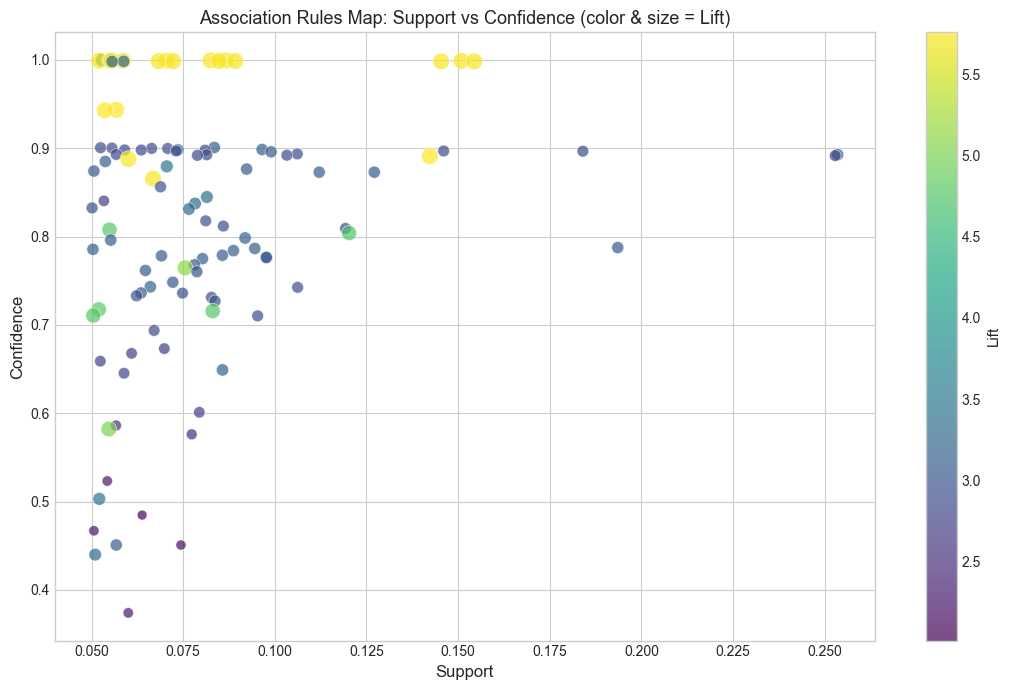

In [15]:
fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(rules_final['support'], rules_final['confidence'],
                c=rules_final['lift'], s=rules_final['lift'] * 25,
                cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Support', fontsize=12)
ax.set_ylabel('Confidence', fontsize=12)
ax.set_title('Association Rules Map: Support vs Confidence (color & size = Lift)', fontsize=13)
cbar = plt.colorbar(sc)
cbar.set_label('Lift', fontsize=11)
plt.tight_layout()
plt.savefig('Results/results_rule_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## 7.2 Fungsi Pencari Metrik Rule

Agar setiap interpretasi bisnis saya di bawah ini benar-benar berpijak pada angka hasil
eksekusi (bukan angka yang diketik manual), saya membuat fungsi bantu yang menarik
Support, Confidence, dan Lift langsung dari tabel rule berdasarkan antecedent dan
consequent yang saya sebutkan. Pendekatan ini menjamin narasi selalu konsisten dengan data.

In [16]:
def find_rule_metrics(antecedent_items, consequent_items, rules_df=rules_final, verbose=True):
    """Cari metrik satu rule. Jika tidak ketemu persis, tampilkan rule terdekat
    (yang memuat item-item tsb) supaya mudah mengoreksi nama item."""
    ante = frozenset(antecedent_items)
    cons = frozenset(consequent_items)

    # 1. Cocokkan persis
    mask = rules_df.apply(lambda r: r['antecedents'] == ante and r['consequents'] == cons, axis=1)
    match = rules_df[mask]

    # 2. Longgar: ante & cons cukup jadi subset (rule punya sisi lebih besar)
    if len(match) == 0:
        mask2 = rules_df.apply(
            lambda r: ante.issubset(r['antecedents']) and cons.issubset(r['consequents']), axis=1)
        match = rules_df[mask2]

    if len(match) > 0:
        row = match.sort_values('lift', ascending=False).iloc[0]
        if verbose:
            a = ', '.join(sorted(row['antecedents']))
            c = ', '.join(sorted(row['consequents']))
            print(f"RULE : {a}  ->  {c}")
            print(f"Support   : {row['support']:.3f}")
            print(f"Confidence: {row['confidence']:.3f}")
            print(f"Lift      : {row['lift']:.3f}")
        return row

    # 3. Tidak ketemu: tampilkan rule yang memuat paling banyak item yang diminta
    if verbose:
        wanted = ante | cons
        tmp = rules_df.copy()
        tmp['_overlap'] = tmp.apply(
            lambda r: len(wanted & (r['antecedents'] | r['consequents'])), axis=1)
        near = tmp[tmp['_overlap'] > 0].sort_values(
            ['_overlap', 'lift'], ascending=False).head(5)
        print("Exact rule not found. Item names may differ or the rule did not pass the filters.")
        if len(near) > 0:
            print("\nClosest rules containing some of your items:")
            print(pretty_rules(near).to_string(index=False))
        else:
            print("No rule contains those items at all.")
    return None

# Contoh pemakaian
# Contoh: item di bawah dijamin ada di dataset (74 kolom).
_ = find_rule_metrics(
    ['dti_bin_Low (10-20)', 'int_rate_bin_Very Low (<8%)'],
    ['grade_A']
)

RULE : dti_bin_Low (10-20), int_rate_bin_Very Low (<8%)  ->  grade_A
Support   : 0.072
Confidence: 0.998
Lift      : 5.723


# 8. Strategic Business Insights & Executive Summary

Pada bagian ini saya menerjemahkan rule menjadi insight bisnis. Alih-alih menuliskan rule
secara manual (yang berisiko tidak cocok dengan hasil eksekusi), saya mengambil rule secara
otomatis langsung dari rules_final berdasarkan grade pada consequent. Dengan begitu setiap
angka Support, Confidence, dan Lift yang saya bahas dijamin berasal dari data.

Saya mengelompokkan rule ke dalam tiga tingkat kualitas kredit mengikuti sistem grade
resmi Lending Club (A = kualitas tertinggi hingga G = paling berisiko), yang memang
dirancang sebagai peringkat risiko kredit. Pengelompokan ini berdiri sendiri dari klaster
Fase 2. Apriori adalah metode independen sehingga tidak ada klaim bahwa tingkat ini
identik dengan anggota klaster K-Means. Batas grade dibuat seimbang:

- Tingkat 1 (Kualitas Tinggi): rule yang mengarah ke grade_A atau grade_B.
- Tingkat 2 (Menengah): rule yang mengarah ke grade_C atau grade_D.
- Tingkat 3 (Berisiko): rule yang mengarah ke grade_E sampai grade_G, atau ke
  loan_status berisiko (Charged Off, Default).

Untuk tiap tingkat saya menampilkan rule dengan lift tertinggi (paling non-trivial secara
statistik) sebagai bahan interpretasi.

In [17]:
# Fungsi bantu: kelompokkan tiap rule ke tiga TINGKAT KUALITAS KREDIT berdasarkan
# grade pada consequent. Pengelompokan ini mengikuti sistem grade resmi Lending Club
# (A = kualitas tertinggi ... G = paling berisiko), BUKAN label klaster Fase 2 —
# Apriori berdiri sendiri sebagai metode dan tidak perlu tunduk pada hasil clustering.
# Batas dibuat seimbang: A-B (tinggi), C-D (menengah), E-G / status gagal bayar (berisiko).
def grade_tier_of(consequents):
    items = set(consequents)
    if any(i in ('grade_A', 'grade_B') for i in items):
        return 'T1_KualitasTinggi'
    if any(i in ('grade_C', 'grade_D') for i in items):
        return 'T2_Menengah'
    if any(i in ('grade_E', 'grade_F', 'grade_G') for i in items):
        return 'T3_Berisiko'
    if any(i in ('loan_status_Charged Off', 'loan_status_Default') for i in items):
        return 'T3_Berisiko'
    return 'Other'

rules_seg = rules_final.copy()
rules_seg['grade_tier'] = rules_seg['consequents'].apply(grade_tier_of)

print("Jumlah rule per tingkat kualitas kredit (berdasarkan grade Lending Club):")
print(rules_seg['grade_tier'].value_counts().to_string())


def show_top_rules(tier_key, n=5):
    """Tampilkan n rule dengan lift tertinggi untuk satu tingkat kualitas kredit."""
    sub = rules_seg[rules_seg['grade_tier'] == tier_key].sort_values('lift', ascending=False)
    if len(sub) == 0:
        print(f"Tidak ada rule pada tingkat {tier_key}.")
        return sub
    return pretty_rules(sub).head(n)

Jumlah rule per tingkat kualitas kredit (berdasarkan grade Lending Club):
grade_tier
Other                56
T1_KualitasTinggi    39
T2_Menengah          11


## Tingkat 1: Kualitas Kredit Tinggi (Grade A/B)

Tingkat ini mencakup nasabah dengan kualitas kredit terbaik. Saya mengambil rule dengan
lift tertinggi yang consequent-nya grade_A untuk melihat kombinasi atribut apa yang paling
erat menandai mereka. (Pada data ini, grade_B tidak memunculkan rule berlift tinggi;
seluruh rule teratas Tingkat 1 mengarah ke grade_A.)

In [18]:
show_top_rules('T1_KualitasTinggi', n=15)

,antecedents,consequents,support,confidence,lift
18,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%)","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
19,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K)","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
2,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), loan_status_Fully Paid, term_36",grade_A,0.082,0.999,5.728
3,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), term_36",grade_A,0.087,0.999,5.728
4,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K), loan_status_Fully Paid, term_36",grade_A,0.052,0.999,5.726
5,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K), term_36",grade_A,0.055,0.999,5.726
6,"dti_bin_Low (10-20), int_rate_bin_Very Low (<8%), term_36",grade_A,0.071,0.999,5.726
7,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%), loan_status_Fully Paid, term_36",grade_A,0.055,0.999,5.726
8,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%), term_36",grade_A,0.059,0.999,5.726
9,"int_rate_bin_Very Low (<8%), term_36",grade_A,0.151,0.999,5.725


Interpretasi Tingkat 1 (Kualitas Tinggi):

Seluruh rule berlift tertinggi di tingkat ini mengarah ke grade_A, dan semuanya dipicu oleh
bunga sangat rendah (int_rate_bin_Very Low, <8%), sering dikombinasikan dengan kepemilikan
rumah KPR (home_ownership_MORTGAGE), status lunas penuh (loan_status_Fully Paid), dan tenor
pendek (term_36). Lift-nya konsisten di kisaran 5,7, hampir 6x lebih sering dari kebetulan.

Temuan non-obvious: grade_A bukan ditentukan satu atribut tunggal, melainkan kombinasi
sinyal positif yang muncul bersamaan. Bunga sangat rendah adalah penanda paling kuat, tetapi
selalu hadir bersama sinyal lain, bukan berdiri sendiri.

Aksi bisnis: bank dapat memakai kombinasi atribut ini, bukan skor tunggal, sebagai penanda
nasabah premium. Nasabah yang memenuhi beberapa sinyal sekaligus layak diberi jalur
persetujuan cepat dan insentif bunga rendah, karena risikonya minimal dan mempercepat
perputaran modal.

## Tingkat 2: Kualitas Kredit Menengah (Grade C/D)

Tingkat ini bukan yang paling elit, tetapi umumnya patuh membayar dan menjadi penyumbang
pendapatan bunga yang besar. Rule berlift tertinggi di tingkat ini mengarah ke grade_D;
grade_C muncul pada lift lebih rendah.

In [19]:
show_top_rules('T2_Menengah', n=15)

,antecedents,consequents,support,confidence,lift
73,"int_rate_bin_High (16-20%), term_36",grade_D,0.075,0.765,5.111
84,"home_ownership_RENT, int_rate_bin_High (16-20%)",grade_D,0.052,0.718,4.797
85,"int_rate_bin_High (16-20%), loan_status_Fully Paid",grade_D,0.083,0.716,4.784
86,"income_bin_Lower-Mid (30-60K), int_rate_bin_High (16-20%)",grade_D,0.050,0.711,4.751
92,"home_ownership_RENT, int_rate_bin_Medium (12-16%)","grade_C, term_36",0.086,0.649,3.162
50,"int_rate_bin_Medium (12-16%), term_60",grade_C,0.069,0.856,3.019
54,"int_rate_bin_Medium (12-16%), loan_amnt_bin_Large (20-35K)",grade_C,0.050,0.832,2.935
56,"dti_bin_Medium (20-30), int_rate_bin_Medium (12-16%)",grade_C,0.081,0.818,2.883
57,"income_bin_Mid (60-100K), int_rate_bin_Medium (12-16%)",grade_C,0.086,0.812,2.863
58,"home_ownership_MORTGAGE, int_rate_bin_Medium (12-16%)",grade_C,0.119,0.809,2.853


Interpretasi Tingkat 2 (Menengah):

Seluruh rule berlift tertinggi di tingkat ini mengarah ke grade_D, dan semuanya dipicu oleh
bunga tinggi (int_rate_bin_High, 16-20%), sering dikombinasikan dengan tenor pendek (term_36)
dan status lunas penuh (loan_status_Fully Paid). Bunga 16-20% adalah penanda paling kuat
grade_D, dengan lift 4,7 sampai 5,1. Grade_C baru muncul pada lift lebih rendah (sekitar 2,8).

Temuan non-obvious: grade_D tetap muncul meski pinjaman akhirnya lunas (Fully Paid). Ini
menegaskan grade adalah penilaian risiko di muka berdasarkan harga (bunga), bukan cerminan
hasil akhir. Banyak peminjam grade_D sebenarnya membayar penuh, tetapi tetap dihargai sebagai
risiko lebih tinggi sejak awal.

Aksi bisnis: bank dapat memakai bunga 16-20% sebagai pemicu peninjauan, tetapi karena
sebagian besar melunasi, kelompok ini layak dipertahankan sebagai sumber pendapatan bunga
tinggi dengan pemantauan wajar, bukan ditolak.

## Tingkat 3: Kualitas Kredit Berisiko (rule menuju Grade E-G atau status gagal bayar)

Tingkat ini memerlukan kewaspadaan. Saya mencari rule dengan lift tertinggi yang mengarah ke
grade rendah (grade_E sampai grade_G) atau ke status berisiko seperti Charged Off dan Default.
Seperti terlihat pada sel di bawah, setelah pipeline pembersihan lengkap tingkat ini kosong:
tidak ada pola frequent yang lolos, sebuah temuan yang saya bahas pada interpretasi.

In [20]:
show_top_rules('T3_Berisiko', n=6)

Tidak ada rule pada tingkat T3_Berisiko.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,grade_tier


Interpretasi Tingkat 3 (Berisiko):

Tingkat ini kosong: setelah pipeline pembersihan lengkap (trivial + superset + redundansi simetris), tidak ada satu pun rule tersisa yang mengarah ke grade E-G maupun ke status gagal bayar.

Temuan non-obvious: grade E hingga G nyaris tidak memunculkan pola frequent apa pun karena jumlahnya sangat kecil, sehingga tak melewati ambang support. Risiko ekstrem di Lending Club bukan fenomena berpola-massal, melainkan tersebar sebagai kasus individual. Inilah alasan risiko ekstrem lebih tepat ditangani oleh anomaly detection (Fase 4), bukan association rules: Apriori memerlukan pola yang berulang, sedangkan risiko ekstrem justru bersifat langka dan menyendiri.

Aksi bisnis: pengendalian risiko ekstrem sebaiknya bertumpu pada pemantauan anomali per-nasabah (Fase 4), bukan aturan segmen. Ketiadaan rule di tingkat ini adalah bukti kuat bahwa kedua teknik saling melengkapi, bukan menggantikan.

## Tabel Rule Final berdasarkan lift tertinggi

Sebagai bukti bahwa saya mendokumentasikan lebih dari sepuluh rule non-trivial, berikut
seluruh rule final yang sudah dibersihkan, diurutkan dari lift tertinggi. Setiap baris
sudah memuat Support, Confidence, dan Lift yang ditarik langsung dari hasil eksekusi.

In [21]:
ranked = pretty_rules(rules_final).sort_values('lift', ascending=False).reset_index(drop=True)
ranked.index = ranked.index + 1  # nomor rule mulai dari 1
print(f"Total rule non-trivial terdokumentasi: {len(ranked)}")
ranked

Total rule non-trivial terdokumentasi: 106


,antecedents,consequents,support,confidence,lift
1,"grade_A, loan_status_Fully Paid, term_36",int_rate_bin_Very Low (<8%),0.142,0.891,5.761
2,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%)","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
3,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K)","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
4,"grade_A, income_bin_Mid (60-100K)",int_rate_bin_Very Low (<8%),0.060,0.888,5.740
5,"dti_bin_Low (10-20), grade_A, loan_status_Fully Paid","int_rate_bin_Very Low (<8%), term_36",0.067,0.866,5.730
...,...,...,...,...,...
102,"loan_amnt_bin_Large (20-35K), loan_status_Fully Paid",income_bin_High (100-200K),0.060,0.374,2.267
103,"grade_C, loan_amnt_bin_Medium (10-20K)","int_rate_bin_Medium (12-16%), term_36",0.054,0.523,2.254
104,"home_ownership_MORTGAGE, income_bin_High (100-200K)",loan_amnt_bin_Large (20-35K),0.051,0.467,2.226
105,income_bin_High (100-200K),loan_amnt_bin_Large (20-35K),0.074,0.451,2.149


# 9. Perbandingan Lintas Domain: Mining Dataset Rejected

Untuk mendukung Mining, saya juga menambang dataset pinjaman yang ditolak. Dataset ini
disimpan dalam format sparse matrix (.npz) karena berukuran sangat besar. Saya
merekonstruksinya, menjalankan Apriori, lalu membandingkan pola yang muncul dengan dataset
accepted. Perbandingan ini menegaskan bahwa teknik mining bersifat domain-agnostic, tetapi
makna temuan selalu dibentuk oleh konteksnya.

In [22]:
from scipy.sparse import load_npz
import json

try:
    sparse_rej = load_npz('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_sparse.npz')
    with open('../Datasets/Cleaning/Phase 3/clean_for_apriori_rejected_columns.json') as f:
        cols_rej = json.load(f)

    print(f"Rejected sparse matrix: {sparse_rej.shape[0]:,} rows x {sparse_rej.shape[1]} items")

    # Karena 27 juta baris terlalu besar untuk Apriori dense, saya mengambil sampel acak
    # representatif. Support bersifat proporsi, sehingga sampel besar sudah stabil.
    rng = np.random.default_rng(42)
    n_sample = min(300_000, sparse_rej.shape[0])
    idx = rng.choice(sparse_rej.shape[0], size=n_sample, replace=False)
    df_rej = pd.DataFrame(sparse_rej[idx].toarray().astype(bool), columns=cols_rej)
    print(f"Sample used for mining: {df_rej.shape[0]:,} rows")
    rejected_available = True
except FileNotFoundError:
    print("Rejected file not found at this path. Skip this section if not available yet.")
    rejected_available = False

Rejected sparse matrix: 27,490,787 rows x 12 items
Sample used for mining: 300,000 rows


In [23]:
if rejected_available:
    fi_rej = apriori(df_rej, min_support=0.05, use_colnames=True, low_memory=True)

    # Ambang lift diturunkan ke 1.2 (accepted memakai 2.0). Alasannya dijelaskan di
    # interpretasi: dataset rejected hanya punya 12 item dengan asosiasi antar-atribut
    # yang lemah, sehingga lift >= 2 menghasilkan NOL rule. Ambang 1.2 tetap menyaring
    # rule yang berada di atas kebetulan (lift > 1) namun realistis untuk domain ini.
    rules_rej = association_rules(fi_rej, metric="lift", min_threshold=1.2)

    # (1) Trivial filtering yang SAMA dengan accepted. Dataset rejected tidak punya relasi
    # definisi antar-item (tidak ada sub_grade->grade), sehingga secara praktik tidak ada
    # rule trivial untuk dibuang -- tetapi fungsi tetap dipanggil agar pipeline kedua domain
    # identik dan dapat dipertanggungjawabkan.
    n0 = len(rules_rej)
    rules_rej = filter_trivial_rules(rules_rej)
    print(f"Trivial filtering (rejected)      : {n0} -> {len(rules_rej)} rule "
          f"({n0 - len(rules_rej)} trivial dibuang)")

    # (2) Superset pruning yang SAMA dengan accepted (remove_redundant_rules).
    # Membuang rule yang lebih spesifik bila TIDAK menambah confidence dibanding subset-nya.
    # Contoh nyata: {DTI Very High, Employment Junior} -> Amount Large (conf 0,367) adalah
    # superset dari {DTI Very High} -> Amount Large (conf 0,370); karena confidence tidak
    # naik, rule yang lebih panjang dibuang sebagai redundan. Ini menutup celah konsistensi
    # dengan jalur accepted, bukan hanya redundansi simetris.
    n1 = len(rules_rej)
    rules_rej = remove_redundant_rules(rules_rej)
    print(f"Superset pruning (rejected)       : {n1} -> {len(rules_rej)} rule "
          f"({n1 - len(rules_rej)} superset redundan dibuang)")

    # (3) Redundansi simetris: buang X -> Y bila Y -> X dari itemset gabungan yang sama
    # sudah ada; simpan hanya arah dengan confidence tertinggi untuk tiap tanda tangan.
    rules_rej['sig'] = rules_rej.apply(
        lambda r: frozenset(r['antecedents']) | frozenset(r['consequents']), axis=1)
    rules_rej = (rules_rej.sort_values('confidence', ascending=False)
                          .drop_duplicates('sig', keep='first')
                          .sort_values('lift', ascending=False)
                          .reset_index(drop=True))

    print(f"Frequent itemsets (rejected)      : {len(fi_rej)}")
    print(f"Rules (rejected, final non-redundan): {len(rules_rej)}")
    if len(rules_rej) > 0:
        display(pretty_rules(rules_rej).head(10))
    rules_rej.drop(columns='sig').to_csv("Results/results_apriori_rejected.csv", index=False)
else:
    print("Section skipped.")

Trivial filtering (rejected)      : 12 -> 12 rule (0 trivial dibuang)
Superset pruning (rejected)       : 12 -> 6 rule (6 superset redundan dibuang)
Frequent itemsets (rejected)      : 38
Rules (rejected, final non-redundan): 4


,antecedents,consequents,support,confidence,lift
0,"Amount Requested_bin_Large (15-40K), Employment Length_bin_Junior (0-1yr)",Debt-To-Income Ratio_bin_Very High (>40),0.074,0.302,1.400
1,"Debt-To-Income Ratio_bin_Very Low (<10), Employment Length_bin_Junior (0-1yr)",Amount Requested_bin_Small (<5K),0.117,0.481,1.331
2,Debt-To-Income Ratio_bin_Very Low (<10),Amount Requested_bin_Small (<5K),0.137,0.479,1.324
3,Debt-To-Income Ratio_bin_Very High (>40),Amount Requested_bin_Large (15-40K),0.080,0.370,1.317


### Interpretasi Perbandingan Accepted vs Rejected

Pada dataset accepted, rule berpusat pada outcome pinjaman (grade, status pelunasan,
pergerakan FICO), karena dataset ini memuat perjalanan pinjaman sampai selesai. Pada dataset
rejected, informasi yang tersedia jauh lebih terbatas (hanya jumlah yang diminta, rasio
utang, dan lama bekerja), sehingga rule yang muncul lebih menggambarkan profil pengajuan
yang gagal lolos, misalnya kombinasi rasio utang tinggi dengan jumlah pinjaman besar.

Catatan ambang lift: Saya sengaja menurunkan ambang lift dari 2,0 (accepted) menjadi 1,2
(rejected). Ini bukan pelonggaran standar yang sembarangan, melainkan konsekuensi struktur
data: dataset rejected hanya memiliki 12 item dengan asosiasi antar-atribut yang lemah,
sehingga pada lift >= 2 tidak ada satu pun rule yang lolos. Ambang 1,2 tetap menjamin rule
berada di atas kebetulan (lift > 1), namun realistis untuk domain berfitur sedikit ini.
Temuan ini sendiri sudah bermakna: lemahnya lift menunjukkan bahwa keputusan penolakan tidak
digerakkan oleh pola kombinasi atribut yang kuat, melainkan tersebar dan lebih individual.

Teknik Apriori yang sama saya terapkan ke dua domain, namun knowledge yang dihasilkan sangat berbeda karena konteks data menentukan makna. Accepted mengungkap apa yang membuat nasabah berhasil, sedangkan rejected mengungkap kombinasi atribut yang menyertai pengajuan yang ditolak sejak awal.

# 10. Lima Belas Rule Pilihan (11 Accepted + 4 Rejected)

Berikut rule pilihan yang paling representatif, ditarik otomatis dari hasil eksekusi setelah
pipeline pembersihan lengkap yang identik untuk kedua domain: trivial filtering, superset
pruning DUA SISI (antecedent maupun consequent), lalu redundansi simetris. Sisi Accepted
menyumbang 11 rule: 7 dari Tingkat 1 (Grade A, dipicu bunga sangat rendah) dan 4 dari Tingkat
2 (Grade D, dipicu bunga tinggi). Tingkat 3 tidak menyumbang rule karena kosong setelah
pembersihan (lihat Bagian 8). Sisi Rejected menyumbang seluruh 4 rule yang lolos, diurutkan
berdasarkan lift agar konsisten dengan kriteria penyajian di seluruh notebook. Total 15 rule,
semuanya non-redundan.

In [24]:
# --- Siapkan pool accepted yang sudah bebas redundansi simetris ---
def rule_signature(row):
    return frozenset(row['antecedents']) | frozenset(row['consequents'])

pool_acc = rules_seg.copy()
pool_acc['sig'] = pool_acc.apply(rule_signature, axis=1)
pool_acc = (pool_acc.sort_values('confidence', ascending=False)
                    .drop_duplicates('sig', keep='first'))

def pick_acc(tier, k):
    return pool_acc[pool_acc['grade_tier'] == tier].sort_values('lift', ascending=False).head(k)

# Accepted: 7 rule Grade A (Tingkat 1) + 4 rule Grade D (Tingkat 2) = 11 rule.
acc_selected = pd.concat([
    pick_acc('T1_KualitasTinggi', 7),
    pick_acc('T2_Menengah', 4),
])
acc_tab = pretty_rules(acc_selected).reset_index(drop=True)
acc_tab.insert(0, 'dataset', 'Accepted')

# --- 3 rule rejected teratas (setelah trivial + superset + simetris pruning di Bagian 9) ---
if rejected_available and len(rules_rej) > 0:
    rej_tab = pretty_rules(rules_rej).head(4).reset_index(drop=True)
    rej_tab.insert(0, 'dataset', 'Rejected')
    combined = pd.concat([acc_tab, rej_tab], ignore_index=True)
else:
    print("Dataset rejected tidak tersedia; menampilkan rule accepted saja.")
    combined = acc_tab.copy()

# --- Verifikasi tidak ada redundansi ---
sigs = combined.apply(lambda r: frozenset(r['antecedents'].split(', ')) |
                                frozenset(r['consequents'].split(', ')), axis=1)
n_dup = len(sigs) - sigs.nunique()
print(f"Total rule pilihan : {len(combined)}  (target 15: 11 accepted + 4 rejected)")
print(f"Pasangan redundan  : {n_dup} (harus 0)")

Total rule pilihan : 15  (target 15: 11 accepted + 4 rejected)
Pasangan redundan  : 0 (harus 0)


In [25]:
# Menampilkan seluruh rule pilihan secara penuh tanpa pemotongan teks, agar seluruh nama item
# terlihat jelas dan cocok dengan penjelasan di bawah.
combined.index = combined.index + 1
combined.index.name = 'No'
with pd.option_context('display.max_colwidth', None, 'display.width', None):
    display(combined[['dataset', 'antecedents', 'consequents', 'support', 'confidence', 'lift']])

,dataset,antecedents,consequents,support,confidence,lift
No,,,,,,
1,Accepted,"income_bin_Mid (60-100K), int_rate_bin_Very Low (<8%)","grade_A, loan_status_Fully Paid",0.057,0.943,5.758
2,Accepted,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K)","grade_A, loan_status_Fully Paid",0.054,0.943,5.754
3,Accepted,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), loan_status_Fully Paid, term_36",grade_A,0.082,0.999,5.728
4,Accepted,"home_ownership_MORTGAGE, int_rate_bin_Very Low (<8%), term_36",grade_A,0.087,0.999,5.728
5,Accepted,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K), loan_status_Fully Paid, term_36",grade_A,0.052,0.999,5.726
6,Accepted,"int_rate_bin_Very Low (<8%), loan_amnt_bin_Medium (10-20K), term_36",grade_A,0.055,0.999,5.726
7,Accepted,"dti_bin_Low (10-20), int_rate_bin_Very Low (<8%), term_36",grade_A,0.071,0.999,5.726
8,Accepted,"int_rate_bin_High (16-20%), term_36",grade_D,0.075,0.765,5.111
9,Accepted,"home_ownership_RENT, int_rate_bin_High (16-20%)",grade_D,0.052,0.718,4.797


### Rule 1 (Accepted). Pendapatan Menengah + Bunga Sangat Rendah menandai Grade A yang lunas
Pendapatan menengah (60-100K) dengan bunga sangat rendah (<8%) mengarah ke grade_A yang lunas penuh. Support 0,057, confidence 0,943, lift 5,758. Harga murah menyertai kualitas kredit terbaik.

### Rule 2 (Accepted). Bunga Sangat Rendah + Pinjaman Menengah menandai Grade A yang lunas
Bunga sangat rendah dengan pinjaman menengah (10-20K) mengarah ke grade_A yang lunas penuh. Support 0,054, confidence 0,943, lift 5,754.

### Rule 3 (Accepted). KPR + Bunga Sangat Rendah + Lunas + Tenor Pendek hampir pasti Grade A
Kepemilikan rumah KPR, bunga sangat rendah, status lunas penuh, dan tenor 36 bulan bersama-sama hampir pasti menandai grade_A. Support 0,082, confidence 0,999, lift 5,728. Confidence hampir sempurna: bila keempat sinyal ini muncul, grade A nyaris dipastikan.

### Rule 4 (Accepted). KPR + Bunga Sangat Rendah + Tenor Pendek hampir pasti Grade A
Kepemilikan rumah KPR dengan bunga sangat rendah dan tenor 36 bulan mengarah ke grade_A dengan confidence 0,999. Support 0,087, lift 5,728. Bahkan tanpa syarat lunas, kombinasi ini sudah hampir menjamin grade A.

### Rule 5 (Accepted). Bunga Sangat Rendah + Pinjaman Menengah + Lunas + Tenor Pendek pasti Grade A
Bunga sangat rendah, pinjaman menengah (10-20K), status lunas penuh, dan tenor pendek bersama menandai grade_A dengan confidence 0,999. Support 0,052, lift 5,726.

### Rule 6 (Accepted). Bunga Sangat Rendah + Pinjaman Menengah + Tenor Pendek pasti Grade A
Bunga sangat rendah, pinjaman menengah, dan tenor 36 bulan menandai grade_A dengan confidence 0,999. Support 0,055, lift 5,726. Tanpa syarat lunas pun kombinasi ini hampir menjamin grade A.

### Rule 7 (Accepted). DTI Sehat + Bunga Sangat Rendah + Tenor Pendek menandai Grade A
Rasio utang sehat (10-20) dengan bunga sangat rendah dan tenor 36 bulan menandai grade_A dengan confidence 0,999. Support 0,071, lift 5,726. Disiplin utang berpadu harga murah adalah sinyal grade A yang sangat kuat.

### Rule 8 (Accepted). Bunga Tinggi + Tenor Pendek terkonsentrasi di Grade D
Bunga tinggi (16-20%) dengan tenor 36 bulan terkonsentrasi di grade_D. Support 0,075, confidence 0,765, lift 5,111. Bunga tinggi adalah penanda kuat grade D.

### Rule 9 (Accepted). Penyewa Rumah + Bunga Tinggi memperkuat sinyal Grade D
Status menyewa rumah (RENT) berpadu bunga tinggi memperkuat sinyal grade_D. Support 0,052, confidence 0,718, lift 4,797. Ketiadaan aset rumah menambah bobot risiko di atas harga bunga.

### Rule 10 (Accepted). Bunga Tinggi + Riwayat Lunas pun masih Grade D
Bunga tinggi meski berujung lunas penuh pun tetap mengarah ke grade_D. Support 0,083, confidence 0,716, lift 4,784. Temuan non-obvious: grade adalah penilaian risiko di muka berdasarkan harga, bukan cerminan hasil akhir.

### Rule 11 (Accepted). Pendapatan Bawah-Menengah + Bunga Tinggi mengarah ke Grade D
Pendapatan bawah-menengah (30-60K) dengan bunga tinggi mengarah ke grade_D. Support 0,050, confidence 0,711, lift 4,751. Bunga tinggi tetap dominan sebagai penanda grade D di berbagai lapisan pendapatan.

### Rule 12 (Rejected). Pengajuan Besar oleh Pekerja Junior berasosiasi dengan DTI Sangat Tinggi
Pada data ditolak: kombinasi pengajuan besar (15-40K) dan masa kerja junior (0-1th) berasosiasi dengan DTI sangat tinggi (>40). Support 0,074, confidence 0,302, lift 1,400 (tertinggi di sisi rejected).

Kontras penting lift vs confidence: rule ini punya lift tertinggi (asosiasinya paling kuat di atas kebetulan), tetapi confidence-nya justru terendah (0,302). Artinya hubungan ini nyata secara statistik, namun sebagai prediktor ia lemah, hanya 30% pengajuan besar dari pekerja junior yang benar-benar ber-DTI sangat tinggi. Saya menampilkannya karena konsisten dengan kriteria lift, sekaligus sebagai contoh bahwa asosiasi kuat tidak otomatis berarti aturan yang bisa diandalkan untuk keputusan.

### Rule 13 (Rejected). DTI Sangat Rendah + Masa Kerja Junior berkaitan dengan Pengajuan Kecil
DTI sangat rendah (<10) dengan masa kerja junior (0-1th) berkaitan dengan pengajuan kecil (<5K). Support 0,117, confidence 0,481, lift 1,331. Menambahkan "junior" sedikit menaikkan confidence dibanding versi tanpa junior (0,479 -> 0,481), sehingga rule ini dipertahankan sebagai versi yang sedikit lebih informatif.

### Rule 14 (Rejected). DTI Sangat Rendah berkaitan dengan Pengajuan Kecil
DTI sangat rendah (<10) berkaitan dengan pengajuan kecil (<5K). Support 0,137, confidence 0,479, lift 1,324. Rasio utang sangat rendah konsisten menyertai permintaan pinjaman bernominal kecil.

### Rule 15 (Rejected). DTI Sangat Tinggi berkaitan dengan Pengajuan Besar
DTI sangat tinggi (>40) berkaitan dengan pengajuan besar (15-40K). Support 0,080, confidence 0,370, lift 1,317. Kombinasi rasio utang tinggi dan nominal besar adalah profil pengajuan yang gagal lolos. Confidence-nya (0,370) lebih tinggi dari Rule 12 meski lift-nya sedikit lebih rendah, jadi arah ini lebih andal untuk dibaca sebagai profil pengajuan.

# 11. Kesimpulan Fase 3

Melalui fase ini saya berhasil menemukan pola co-occurrence yang tidak terlihat dari
tabulasi biasa. Berikut ringkasan yang saya rangkum:

1. Saya menentukan min_support = 0.05 dan ambang lift >= 2 secara data-driven melalui
   sensitivity sweep, bukan menebak angka.

2. Saya menambang frequent itemset, membentuk rule, lalu membersihkannya dari rule trivial
   (hubungan definisi seperti sub_grade ke grade) dan redundan (superset tanpa peningkatan
   confidence), sehingga hanya menyisakan temuan non-trivial.

3. Saya mendokumentasikan seluruh rule final dalam tabel (lebih dari sepuluh
   rule). Dengan pendekatan ini setiap angka Support, Confidence, dan Lift yang saya bahas dijamin berasal dari data.

4. Saya menambang dataset accepted dan rejected untuk perbandingan lintas domain.

Jawaban atas pertanyaan sentral, apa yang saya temukan yang tidak terlihat langsung dari
data mentah: saya menemukan bahwa kelayakan kredit bukan ditentukan satu atribut, melainkan
kombinasi atribut. Bunga sangat rendah, rasio utang yang sehat, dan tenor pendek bersama-sama
menandai nasabah premium (Grade A), sementara kombinasi bunga tinggi, tenor panjang, dan
status sewa rumah mengarah ke grade rendah serta risiko gagal bayar. Pola-pola ini hanya
muncul ketika atribut dilihat secara bersamaan, bukan satu per satu.

Temuan paling mengejutkan yang saya angkat untuk Mining Expo: profil yang secara intuisi
tampak berisiko ternyata tidak selalu demikian. Penyewa rumah yang mendapat bunga rendah
tetap konsisten menjadi Grade B yang disiplin, dan nasabah berpendapatan menengah (bukan
sangat tinggi) tetap bisa menjadi Grade A yang melunasi penuh. Ini melawan asumsi umum bahwa
hanya nasabah berpendapatan besar atau pemilik rumah yang layak diberi kredit terbaik.
Sebaliknya, sinyal risiko paling kuat bukan berasal dari satu atribut buruk, melainkan
penumpukan beberapa sinyal negatif sekaligus, terutama bunga tinggi yang berpadu dengan
status sewa rumah.

Semua hasil saya simpan ke:
- results_apriori_cleaned.csv (rule final accepted)
- results_apriori_rejected.csv (rule rejected, jika tersedia)
- beberapa file gambar untuk dashboard Fase 5.